# Bates: stochastic volatility with jumps

Two threads from earlier weeks converge here. Heston (Week 4) gave the price a
stochastic variance, which produces a realistic term structure of volatility but
is Markovian and mean-reverting, so its smile flattens too fast at short
maturities. Merton and Kou (Week 7) added jumps, which produce steep short-dated
skew a pure diffusion cannot, but on a constant-vol diffusion they miss the term
structure and, on real SPX, could only reach the steep 29 DTE skew by degenerating
to a near one-sided fit.

Bates (1996) combines them: Heston's stochastic variance *and* Merton's jumps in
the price. The division of labour is exactly what the two earlier failures asked
for. Stochastic vol supplies the term structure; jumps supply the short-dated
tail. This notebook derives the Bates characteristic function as a composition of
the two pieces we have already built and certified, then (tomorrow) implements and
validates it, reusing the model-agnostic COS core.

## 1. The model

Under the risk-neutral measure, the price carries a stochastic-variance diffusion
plus a compound Poisson jump, and the variance follows the Heston CIR process:

$$\frac{dS_t}{S_t} = (r - q - \lambda\kappa_J)\,dt + \sqrt{v_t}\,dW_t^S + dJ_t$$

$$dv_t = \kappa_v(\theta - v_t)\,dt + \xi\sqrt{v_t}\,dW_t^v, \qquad dW_t^S\,dW_t^v = \rho\,dt$$

The jump $dJ_t$ is Merton's: arrivals at Poisson rate $\lambda$, log-jump sizes
$Y \sim \mathcal{N}(\mu_J, \delta_J^2)$.

**A notation clash to settle first.** Heston's mean-reversion speed is
conventionally $\kappa$, and the Merton jump compensator is also conventionally
$\kappa$. They are unrelated. Throughout, the Heston mean-reversion is $\kappa_v$
and the jump compensator is

$$\kappa_J = \mathbb{E}[e^Y - 1] = e^{\mu_J + \frac12\delta_J^2} - 1.$$

Confusing them in code would be a silent disaster, so the names stay distinct
($\kappa_v$, `kappa_v`; $\kappa_J$, `kappa_j`).

The full parameter set is Heston's five, $v_0, \kappa_v, \theta, \xi, \rho$, plus
Merton's three, $\lambda, \mu_J, \delta_J$. Eight parameters. That richness is the
point (it can fit both term structure and short-dated skew), but it also
foreshadows a calibration problem: jumps and diffusion both add short-dated
variance, so they are partly redundant, and the fit may not pin them separately.
That identifiability tension is a theme for the calibration day.

## 2. The characteristic function is a composition

Here the Week 7 insight pays off directly. The log-price has two *independent*
sources of randomness: the Heston diffusion-with-stochastic-vol part, and the
compound Poisson jump part. Independent random variables have characteristic
functions that multiply, because the expectation of a product of independent
things factorises:

$$\phi_{\text{Bates}}(u) = \mathbb{E}\!\left[e^{iu(X_{\text{Heston}} + X_{\text{jump}})}\right]
= \mathbb{E}\!\left[e^{iuX_{\text{Heston}}}\right]\,\mathbb{E}\!\left[e^{iuX_{\text{jump}}}\right]
= \phi_{\text{Heston}}(u)\,\phi_{\text{jump}}(u).$$

The jump factor is exactly Merton's, derived in Week 7 via conditioning on the
number of jumps (Levy-Khintchine form):

$$\phi_{\text{jump}}(u) = \exp\!\Big(\lambda\tau\big[e^{iu\mu_J - \frac12 u^2\delta_J^2} - 1\big]\Big).$$

So nothing is re-derived from scratch. Bates is Heston's characteristic function
times Merton's jump factor, and both are already coded and certified. The model
is a *composition*, not a new derivation.

## 3. The one subtlety: the compensator, and not double-counting drift

Composition is not quite "multiply the two standalone characteristic functions,"
and the reason is the drift.

Each model, standalone, carries its own drift that makes its *own* discounted
price a martingale. Our `heston_char_func` carries a drift term $r\,iu\,\tau$
inside its $C$ function (and nothing else in it depends on $r$). Our
`merton_char_func`, standalone, carries drift $(r - q - \lambda\kappa_J)$,
including the jump compensator $-\lambda\kappa_J$.

If we naively multiplied the two *full* characteristic functions, the $(r-q)$
drift would appear twice, once from each, and the product would carry $2(r-q)$
of drift. Not a martingale.

The martingale condition tells us exactly how much drift the assembled function
may carry. Every model must satisfy

$$\phi(-i) = \mathbb{E}[S_T] = S_0\,e^{(r-q)\tau},$$

because at $u = -i$ the transform $e^{iu\ln S_T}$ becomes $e^{\ln S_T} = S_T$.
So the total drift must be exactly $(r-q)$ from the diffusion side, and the jump
side must be *compensated* by $-\lambda\kappa_J$ so the jumps add no net growth.

**The clean assembly.** Take Heston's characteristic function carrying the
$(r-q)$ diffusion drift, and multiply by the pure jump factor (no drift) *and* an
explicit compensator term:

$$\phi_{\text{Bates}}(u) = \phi_{\text{Heston}}^{(r-q)}(u)
\cdot \underbrace{e^{iu(-\lambda\kappa_J\tau)}}_{\text{compensator, once}}
\cdot \underbrace{\exp\!\Big(\lambda\tau\big[e^{iu\mu_J - \frac12 u^2\delta_J^2} - 1\big]\Big)}_{\text{jump factor}}.$$

Three factors, each carrying exactly one thing:

- **Heston** carries the $(r-q)$ diffusion drift and the stochastic-vol dynamics.
- **The compensator** $e^{iu(-\lambda\kappa_J\tau)}$ carries the jump-drift
  correction, added once because Heston has no jump knowledge.
- **The jump factor** carries the pure jump randomness, no drift.

So $(r-q)$ appears once and $-\lambda\kappa_J$ appears once. Martingale-consistent
by construction, and the check $\phi(-i) = S_0 e^{(r-q)\tau}$ confirms it.

**Reusing the code.** `heston_char_func` is reused directly, with $(r-q)$ passed
into its $r$-slot (legal because its drift is a single $r\,iu\,\tau$ term with
nothing else riding on $r$). `merton_char_func` is *not* reused wholesale, since
its built-in $(r-q)$ drift would double-count against Heston; only Merton's jump
factor plus the explicit compensator are used.

## 4. The cumulants

The COS truncation range $[a, b]$ needs the first two cumulants of $\log S_T$.
Cumulants live in log-characteristic-function space: since the characteristic
functions multiply, their logs add, and the cumulants (Taylor coefficients of
$\log\phi$) add term by term. So the Bates cumulants are the Heston cumulants plus
the jump cumulants:

$$c_1 = c_1^{\text{Heston}}(r-q) + \lambda\tau\mu_J - \lambda\kappa_J\tau$$

$$c_2 = c_2^{\text{Heston}} + \lambda\tau(\mu_J^2 + \delta_J^2)$$

The $-\lambda\kappa_J\tau$ in $c_1$ is the compensator shifting the mean; the
$\lambda\tau(\mu_J^2 + \delta_J^2)$ in $c_2$ is the jump variance via the
compound-Poisson second moment $\mathbb{E}[Y^2] = \mu_J^2 + \delta_J^2$ (the
$\mu_J^2$ term is easy to drop and doing so narrows the range and loses wing
accuracy). Both reuse the Heston cumulants with $(r-q)$, plus the same Merton jump
terms as Week 7.

Because Bates carries *both* stochastic-vol fat tails and jump fat tails, it is
more truncation-hungry than either alone. Expect to need a wider range $L$ and
more terms $N$ than Heston or Merton, the same lesson Kou taught when its
double-exponential tails demanded a wider $L$. The needed values are validated,
not assumed.

## 5. Why Bates should succeed where the halves failed

The empirical motivation is concrete, from the earlier weeks:

- **Heston alone** fits the term structure of volatility but, being Markovian and
  mean-reverting, flattens the smile too fast at short maturities. It cannot make
  a 29 DTE skew as steep as the market prices.
- **Jumps alone** (Merton, Kou on a constant-vol diffusion) make steep short-dated
  skew, but on real SPX could only reach it by degenerating (Kou's up-jump
  probability collapsed to near zero, a one-sided fit), and they carry no term
  structure of their own.

Bates has both ingredients. The stochastic variance handles how the smile evolves
across maturities; the jumps inject the short-dated tail weight that the diffusion
lacks. The expectation is that Bates fits the whole surface (short and long
maturities together) better than any of its constituents alone, and with less
degenerate parameters than the pure jump models needed.

Whether it delivers, and whether the eight parameters are identifiable from the
data or just partly redundant, is the calibration question. As always, more
parameters fit better almost by definition, so the honest test is whether the
improvement is meaningful and the fitted parameters are sensible, not whether the
number goes down.

In [1]:
# Imports. Reuse the certified pieces; Bates is a composition.
import numpy as np
import matplotlib.pyplot as plt

from models.bates import bates_char_func, bates_cumulants   
from pricing.fourier import bates_cos_price, cos_call_price
from models.heston import heston_char_func, heston_cumulants, simulate_heston_paths

from calibration.implied_vol import bsm_implied_vol
from pricing.fourier import cos_smile

## 6. Demos

In [2]:
# Truncation Sweep:
S0, v0, kappa_v, theta, xi, rho = 100.0, 0.04, 2.0, 0.04, 0.3, -0.7
r, q, tau, K = 0.03, 0.01, 0.5, 100.0
lam, mu_j, delta_j = 0.5, -0.10, 0.15
parity_rhs = S0*np.exp(-q*tau) - K*np.exp(-r*tau)

print("L sweep (N=256):")
for L in [8, 10, 12, 16, 20]:
    c = bates_cos_price(S0, v0, kappa_v, theta, xi, rho, r, q, tau, K, lam, mu_j, delta_j, "call", N=256, L=L)
    p = bates_cos_price(S0, v0, kappa_v, theta, xi, rho, r, q, tau, K, lam, mu_j, delta_j, "put", N=256, L=L)
    print(f"  L={L:2d}: parity residual = {abs((c-p) - parity_rhs):.2e}")

print("N sweep (L=12):")
for N in [64, 128, 256, 512]:
    c = bates_cos_price(S0, v0, kappa_v, theta, xi, rho, r, q, tau, K, lam, mu_j, delta_j, "call", N=N, L=12)
    p = bates_cos_price(S0, v0, kappa_v, theta, xi, rho, r, q, tau, K, lam, mu_j, delta_j, "put", N=N, L=12)
    print(f"  N={N:3d}: parity residual = {abs((c-p) - parity_rhs):.2e}")

L sweep (N=256):
  L= 8: parity residual = 1.07e-05
  L=10: parity residual = 1.72e-07
  L=12: parity residual = 2.41e-09
  L=16: parity residual = 8.14e-13
  L=20: parity residual = 4.91e-11
N sweep (L=12):
  N= 64: parity residual = 2.82e-05
  N=128: parity residual = 1.54e-09
  N=256: parity residual = 2.41e-09
  N=512: parity residual = 2.41e-09


### Truncation: Bates needs a wider range, and wider is not always better

Bates carries two fat-tail sources (stochastic-vol and jumps), so it is more
truncation-hungry than either parent. Sweeping the COS range $L$ and resolution
$N$ against put-call parity (a difference of two separately-truncated prices, so
truncation error shows up doubled) confirmed the defaults and surfaced a real
numerical trade-off.

**$N$ (resolution):** the residual falls from $2.8\times10^{-5}$ at $N=64$ to
$\sim10^{-9}$ by $N=128$, then plateaus, $N=128, 256, 512$ all sit at the same
floor. Resolution converged by $N=128$; past that the error is set by the range,
not resolution, so more terms cannot help. Default $N=256$ is comfortably past
convergence.

**$L$ (range):** the residual improves $10^{-5} \to 10^{-7} \to 10^{-9} \to
8\times10^{-13}$ as $L$ goes $8 \to 16$, then *worsens* to $5\times10^{-11}$ at
$L=20$. The non-monotonicity is not noise, it is the range-resolution trade-off.
Widening $L$ captures more of the fat tail (truncation error falls) but spreads
the same $N$ cosine terms over a wider domain (resolution per unit $k$ coarsens).
Below the optimum, truncation dominates and wider helps; above it, the tail is
already fully captured and the only effect of widening is lost resolution, so the
residual rises again. The optimum here is $L \approx 16$.

Two lessons. First, this is the Kou fat-tail lesson seen from the other side: Kou
showed too-narrow clips the tail; Bates shows too-wide starves the resolution.
There is an optimum in between, and it shifts with tail fatness and $N$. Second,
the practical fix for a wing that looks slightly off is *not* reflexively
widening $L$, overshooting hurts. If $L$ is already wide, the remedy is more $N$
(restore resolution), not yet more $L$.

The default $L=12$ gives a $2.4\times10^{-9}$ parity residual, sub-nanodollar on
a $\sim\$6$ option, more than adequate for any real use. $L=16$ is the true
optimum for these parameters if maximal precision is ever wanted, but there is no
need. $N=256, L=12$ is validated for calibration.

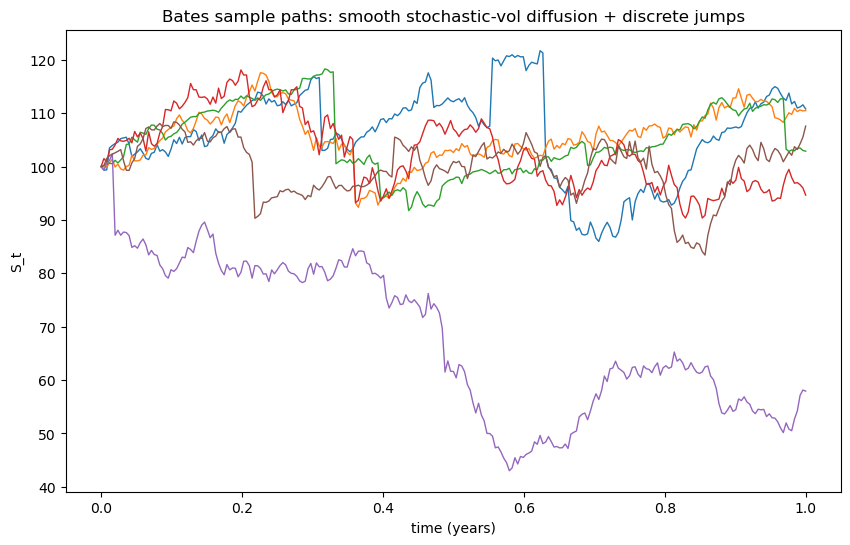

In [3]:
def bates_paths_demo(S0, v0, kappa_v, theta, xi, rho, r, q, tau,
                     lam, mu_j, delta_j, n_paths, n_steps, seed=None):
    """Full Bates paths with jumps placed at their actual step times, for
    visualization. Returns (S_paths, jump_times_mask). Demo only."""
    rng = np.random.default_rng(seed)
    kappa_j = np.exp(mu_j + 0.5 * delta_j**2) - 1.0
    r_adj = r - q - lam * kappa_j
    dt = tau / n_steps

    # Heston path with the Bates diffusion drift
    S_heston, v = simulate_heston_paths(S0, v0, kappa_v, theta, xi, rho, r_adj,
                                        tau, n_steps, n_paths, rng=rng)
    log_S = np.log(S_heston)

    # jumps per step: each step, each path jumps w.p. lam*dt, size ~ N(mu_j, delta_j^2)
    jumped = rng.random((n_paths, n_steps)) < lam * dt
    sizes = rng.normal(mu_j, delta_j, size=(n_paths, n_steps)) * jumped
    # accumulate jump contributions forward along the path
    cum_jumps = np.cumsum(sizes, axis=1)
    log_S[:, 1:] += cum_jumps

    return np.exp(log_S), jumped

# a handful of paths, jumpy params so jumps are visible
S, jumped = bates_paths_demo(100, 0.04, 2.0, 0.04, 0.3, -0.7, 0.03, 0.0, 1.0,
                             lam=3.0, mu_j=-0.08, delta_j=0.06,
                             n_paths=6, n_steps=252, seed=1)
t = np.linspace(0, 1, 253)
fig, ax = plt.subplots(figsize=(10, 6))
for i in range(6):
    ax.plot(t, S[i], lw=1)
ax.set_xlabel("time (years)"); ax.set_ylabel("S_t")
ax.set_title("Bates sample paths: smooth stochastic-vol diffusion + discrete jumps")
plt.show()

### Paths: the two mechanisms are visible

The sample-path plot makes Bates's construction concrete. Between jumps, each
path wiggles continuously, that is the Heston diffusion, and the wiggle
amplitude itself breathes over time as the stochastic variance $v_t$ rises and
falls. Punctuating the diffusion are discrete vertical gaps where the price
teleports, the compound-Poisson jumps. With $\mu_J < 0$ the large jumps lean
downward, the crash direction. One path shows the whole model in miniature: an
early downward jump to $\sim 87$, then a volatile stochastic-vol journey down to
$\sim 43$ and back. Jump for the sudden crash, diffusion for the meander.

(The demo uses $\lambda = 3$ for visibility; at the calibration-scale
$\lambda \approx 0.5$ you would rarely see a jump in a single one-year path. The
picture exaggerates the mechanism, it is not a claim about SPX jump frequency.)


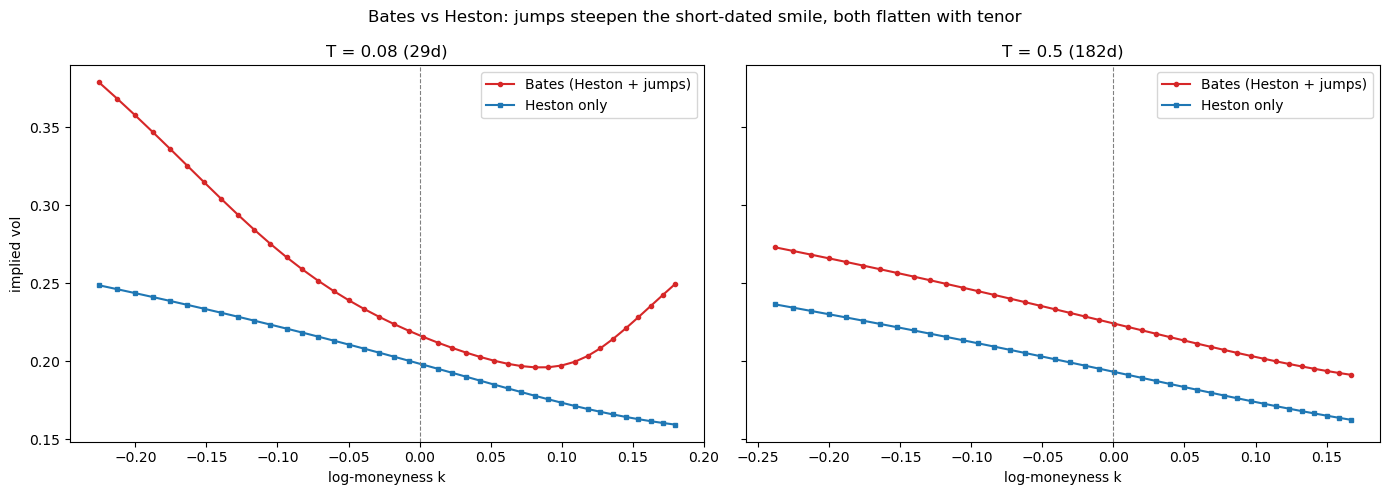

In [4]:
# shared params: same Heston core, Bates adds jumps on top
v0, kappa_v, theta, xi, rho = 0.04, 2.0, 0.04, 0.3, -0.7
r, q = 0.03, 0.0
lam, mu_j, delta_j = 0.5, -0.10, 0.15
S0 = 100.0

maturities = [0.08, 0.5]          # short (~29d) and long (~6mo)
strikes = np.linspace(80, 120, 40)

def iv_from_price(price, K, T):
    return bsm_implied_vol(price, S0, K, T, r, "call", b=r - q)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, T in zip(axes, maturities):
    F = S0 * np.exp((r - q) * T)
    k = np.log(strikes / F)

    # Bates smile
    bates_px = np.array([bates_cos_price(S0, v0, kappa_v, theta, xi, rho, r, q, T, K,
                                         lam, mu_j, delta_j, "call") for K in strikes])
    bates_iv = [iv_from_price(p, K, T) for p, K in zip(bates_px, strikes)]

    # Heston smile (same core, no jumps) via cos_smile at r-q
    heston_px = cos_smile(S0, v0, kappa_v, theta, xi, rho, r - q, T, strikes, "call")
    heston_iv = [iv_from_price(p, K, T) for p, K in zip(heston_px, strikes)]

    ax.plot(k, bates_iv, "o-", color="tab:red", ms=3, label="Bates (Heston + jumps)")
    ax.plot(k, heston_iv, "s-", color="tab:blue", ms=3, label="Heston only")
    ax.axvline(0, color="gray", ls="--", lw=0.8)
    ax.set_xlabel("log-moneyness k"); ax.set_title(f"T = {T} ({T*365:.0f}d)")
    ax.legend()
axes[0].set_ylabel("implied vol")
fig.suptitle("Bates vs Heston: jumps steepen the short-dated smile, both flatten with tenor")
plt.tight_layout()
plt.show()

### Smiles: jumps steepen the short end, both flatten with tenor

The two-panel smile comparison is the payoff, and it answers the Week 7 puzzle
directly. At short maturity (29 days), Heston alone produces a shallow,
nearly-linear skew, a diffusion cannot put much weight far from the money over a
short horizon because its short-dated tails are thin. Bates lifts this into a
pronounced smile: a steep left wing, a clear ATM trough, even a right-wing
upturn. The jumps did not merely shift the smile up, they changed its shape,
injecting curvature and downside steepness exactly where Heston is flat. The
gap between the two curves, largest in the wings and smallest near the money, is
the jump contribution, and it lives precisely where jumps matter.

At the longer maturity (six months) the two nearly converge. A fixed jump
intensity contributes a fixed amount of tail weight, but accumulated diffusion
variance grows with $T$, so the jumps' relative impact shrinks and Bates relaxes
toward the Heston shape.

Together the panels show the term structure of the skew's steepness: violent at
the short end, gentle at the long end. This is the behaviour no single-mechanism
model could produce. Heston alone flattens too fast at the short end (its Week 7
failing); pure jumps on a constant-vol diffusion give short-dated steepness but
no term structure at all. Bates has both mechanisms, stochastic vol for the
baseline term structure, jumps for the short-dated tail, so it reproduces the
steep-short, gentle-long skew pattern seen in real SPX (the steep 29 DTE $\rho$
relaxing with maturity, from Week 6).

These are illustrative parameters, not a fit, so the magnitudes are chosen to
make the effect visible. The calibration day tests whether real SPX actually
wants this much jump, and whether the eight parameters are identifiable or
partly redundant.